## ¿Qué es una puerta cuántica?

Una **puerta cuántica** es una operación que actúa sobre uno o varios **qubits** para cambiar su estado. A diferencia de las compuertas clásicas (como AND, OR, NOT), las puertas cuánticas trabajan sobre **superposiciones** de estados y permiten fenómenos como la **interferencia** y el **entrelazamiento**.

Matemáticamente, una puerta cuántica se representa mediante una **matriz unitaria**, es decir, una matriz $U$ que cumple:

$$
U^\dagger U = I
$$

Donde $ U^\dagger $ es la conjugada transpuesta de $ U $, e $ I $ es la matriz identidad.

---

### 🔹 ¿Por qué las puertas cuánticas deben ser unitarias?

Las **matrices unitarias** conservan la **norma** (longitud) del vector de estado, lo cual es necesario para mantener la **probabilidad total igual a 1** en un sistema cuántico.

> ⚠️ Si una puerta no fuera unitaria, podría provocar que las probabilidades no sumen 1, lo que violaría las reglas de la mecánica cuántica.

---


### Puerta X (NOT Cuántico)

- **Matriz:**
  $$
  X = 
  \begin{bmatrix}
  0 & 1 \\
  1 & 0
  \end{bmatrix}
  $$

- **Descripción:**
  Invierte los estados $|0\rangle \leftrightarrow |1\rangle$. Equivalente al NOT clásico.

- **Rotación en la esfera de Bloch:** $ \pi $ radianes alrededor del eje X.

---

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_vector, plot_state_city, plot_bloch_multivector
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# create a quantum circuit and its register objects

qreg =  QuantumRegister(1)

creg =  ClassicalRegister(1)


## Representación de un qubit en la esfera de Bloch

Cualquier **estado puro** de un qubit puede escribirse como:

$$
|\psi\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + e^{i\phi} \sin\left(\frac{\theta}{2}\right)|1\rangle
$$

Donde:

- $ \theta $: ángulo polar (entre 0 y $ \pi $)
- $ \phi $: ángulo azimutal (entre 0 y $ 2\pi $)

---

### Parámetro $ \theta $ – Rotación desde el eje Z

- Es el **ángulo polar**.
- Cuantifica la **mezcla** entre los estados $ |0\rangle $ y $ |1\rangle $.
- Define la posición "vertical" del vector en la esfera de Bloch.
- Ejemplos:
  - $ \theta = 0 $ → $ |\psi\rangle = |0\rangle $ (norte)
  - $ \theta = \pi $ → $ |\psi\rangle = |1\rangle $ (sur)
  - $ \theta = \frac{\pi}{2} $ → máxima superposición (ecuador)

---

### Parámetro $ \phi $ – Fase relativa

- Es el **ángulo azimutal**.
- Define la **fase relativa** entre $ |0\rangle $ y $ |1\rangle $.
- Determina la **dirección en el plano X-Y** de la esfera.
- Directamente afectado por puertas como `Z`, `S`, `T`.

Ejemplos en el ecuador ($ \theta = \frac{\pi}{2} $):

- $ \phi = 0 $: vector apunta al eje X positivo → $ |+\rangle $
- $ \phi = \pi $: vector apunta al eje X negativo → $ |-\rangle $
- $ \phi = \frac{\pi}{2} $: eje Y positivo → $ \frac{1}{\sqrt{2}}(|0\rangle + i|1\rangle) $

---


### Puerta Y

- **Matriz:**
  $$
  Y = 
  \begin{bmatrix}
  0 & -i \\
  i & 0
  \end{bmatrix}
  $$

- **Descripción:**
  Gira el estado $ \pi $ radianes alrededor del eje Y.

- **Efecto cuántico:** cambia tanto la amplitud como la fase.


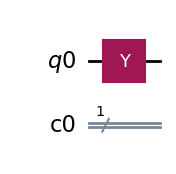

In [4]:
#Definicion del circuito

qc_y = QuantumCircuit(qreg, creg)

qc_y.y(0)

# qc.draw('latex')

qc_y.draw(output="mpl")

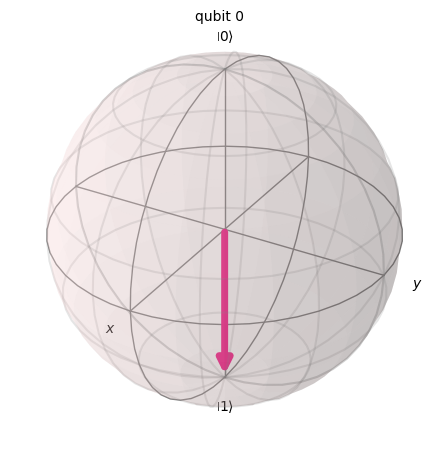

In [5]:
#Statevector
state_y = Statevector.from_instruction(qc_y)

#Bloch Sphere
plot_bloch_multivector(state_y)

In [6]:
#Cálculo theta y phi

a, b = state_y.data

# Normalización (si fuera necesario)

norm = np.sqrt(np.abs(a)**2 + np.abs(b)**2)
a, b = a / norm, b/norm

theta = 2 * np.arccos(np.real(a))
phi = np.angle(b) 
print(theta)
print(phi)

3.141592653589793
1.5707963267948966


### Puerta Z

- **Matriz:**
  $$
  Z = 
  \begin{bmatrix}
  1 & 0 \\
  0 & -1
  \end{bmatrix}
  $$

- **Descripción:**
  Cambia la fase de $|1\rangle$, pero deja $|0\rangle$ sin cambios.

- **Rotación:** $ \pi $ radianes alrededor del eje Z.


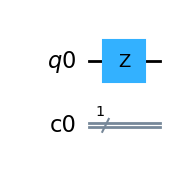

In [9]:
#Definicion del circuito
#From |0>

qc_z = QuantumCircuit(qreg, creg)

qc_z.z(0)

qc_z.draw(output="mpl")

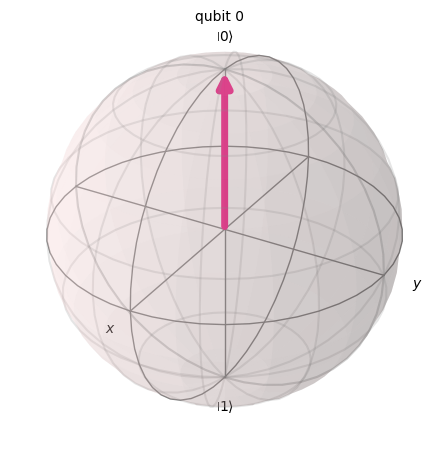

In [10]:
#Statevector
state_z = Statevector.from_instruction(qc_z)

#Bloch Sphere
plot_bloch_multivector(state_z)

In [12]:
#Calculo theta y phi

a, b = state_z.data

# Normalización (si fuera necesario)

norm = np.sqrt(np.abs(a)**2 + np.abs(b)**2)
a, b = a / norm, b/norm

theta = 2 * np.arccos(np.real(a))
phi = np.angle(b) 
print(theta)
print(phi)

0.0
0.0


      
  q0: 
      
c0: 1/
      
      ┌───┐
  q0: ┤ X ├
      └───┘
c0: 1/═════
           
      ┌───┐┌───┐
  q0: ┤ X ├┤ Z ├
      └───┘└───┘
c0: 1/══════════
                


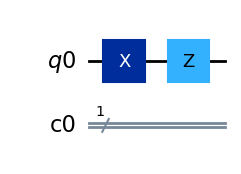

In [ ]:
#Definicion del circuito
#From |1>

qc_z1 = QuantumCircuit(qreg, creg)

print(qc_z1)

qc_z1.x(0)

qc_z1.z(0)

qc_z1.draw(output="mpl")

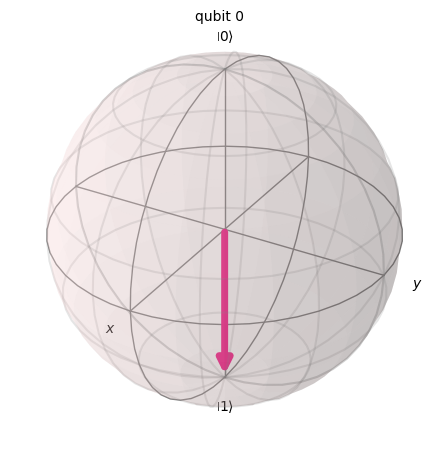

In [15]:
#Statevector
state_z1 = Statevector.from_instruction(qc_z1)


#Bloch Sphere
plot_bloch_multivector(state_z1)

In [16]:
#Calculo de theta y phi
a,b = state_z1.data

print(a, b)
# Normalización (por si acaso)



print(theta)
print(phi)

0j (-1+0j)
0.0
0.0


### Puerta S (Fase)

- **Matriz:**
  $$
  S = 
  \begin{bmatrix}
  1 & 0 \\
  0 & i
  \end{bmatrix}
  $$

- **Descripción:**
  Aplica una rotación de $ \frac{\pi}{2} $ alrededor del eje Z.

- **Efecto:** agrega una fase de $ \frac{\pi}{2} $ al estado $|1\rangle$.


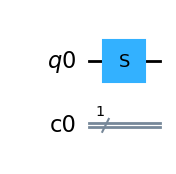

In [20]:
#Definicion del circuito

qc_s = QuantumCircuit(qreg, creg)

qc_s.s(0)

qc_s.draw(output="mpl")

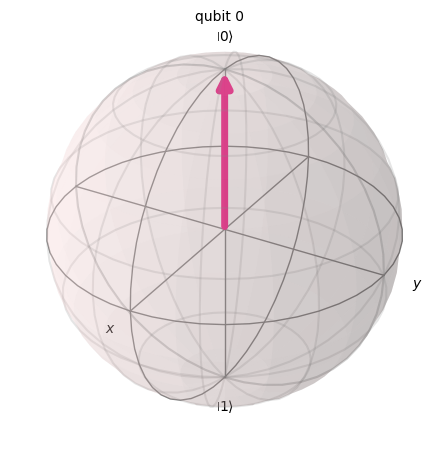

In [21]:
#Statevector
state_s = Statevector.from_instruction(qc_s)

#Bloch Sphere
plot_bloch_multivector(state_s) 

In [22]:
#Calculo theta y phi

print(theta)
print(phi)

0.0
0.0


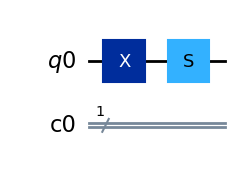

In [23]:
#Definicion del circuito
#from |1>
qc_s1 = QuantumCircuit(qreg, creg)

qc_s1.x(0)

qc_s1.s(0)
qc_s1.draw(output="mpl")

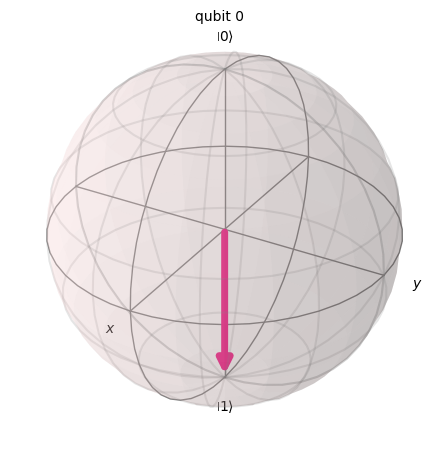

In [24]:
#Statevector
state_s1 = Statevector.from_instruction(qc_s1)

#Bloch Sphere
plot_bloch_multivector(state_s1) 

In [25]:
#Calculo theta y phi


print(theta)
print(phi)

0.0
0.0


### Puerta T (Fase $\frac{\pi}{4}$)

- **Matriz:**
  $$
  T = 
  \begin{bmatrix}
  1 & 0 \\
  0 & e^{i\pi/4}
  \end{bmatrix}
  $$

- **Descripción:**
  Aplica una rotación de $ \frac{\pi}{4} $ alrededor del eje Z.

- **Efecto:** agrega una fase de $ \frac{\pi}{4} $ al estado $|1\rangle$.

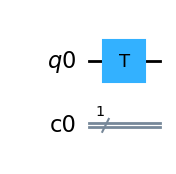

In [26]:
#Definicion del circuito
#from |0>
qc_t = QuantumCircuit(qreg, creg)

qc_t.t(0)

qc_t.draw(output="mpl")

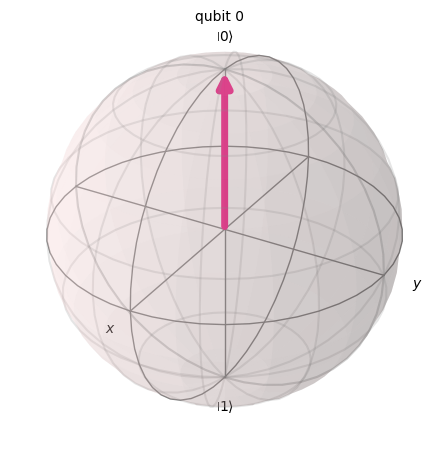

In [27]:
#Statevector
state_t = Statevector.from_instruction(qc_t)

#Bloch Sphere
plot_bloch_multivector(state_t) 

In [28]:
#Calculo theta y phi
a,b = state_t.data

print(theta)
print(phi)

0.0
0.0


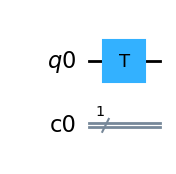

In [30]:
#Definicion del circuito
#from |1>
qc_t1 = QuantumCircuit(qreg, creg)

#qc_t1.(0)

qc_t1.t(0)

qc_t1.draw(output="mpl")

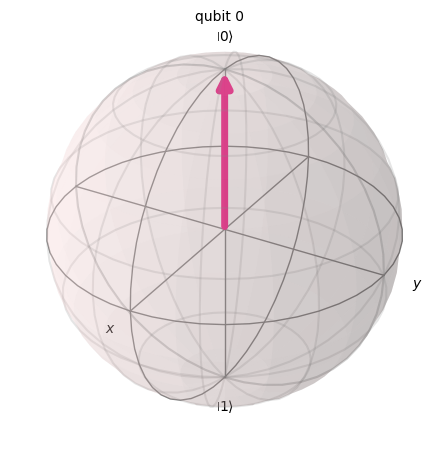

In [31]:
#Statevector
state_t1 = Statevector.from_instruction(qc_t1)

#Bloch Sphere
plot_bloch_multivector(state_t1) 

In [ ]:
#Calculo theta y phi


print(theta)
print(phi)

| Puerta | Eje de Rotación | Cambia fase |  Observación en la esfera |
| ------ | --------------- | ----------- |  ------------------------ |
| X      |                 |             |                           |
| Y      |                 |             |                           |
| Z      |                 |             |                           |
| H      |                 |             |                           |
| S      |                 |             |                           |
| T      |                 |             |                           |


## ¿Qué es la unitariedad?

Una **matriz unitaria** es una matriz cuadrada compleja $ U $ que cumple la propiedad:

$$
U^\dagger U = UU^\dagger = I
$$

Donde:
- $ U^\dagger $ es la **conjugada transpuesta** (adjunta) de $ U $
- $ I $ es la **matriz identidad**

---

## ¿Qué significa?

Una operación **unitaria**:
- **Preserva la norma** (longitud) del vector sobre el que actúa.
- **No cambia la probabilidad total** (sigue siendo 1).
- **No pierde información**: es **reversible**.
- Es como una **rotación** (en un espacio complejo), no un estiramiento ni una compresión.

---

## Importancia en computación cuántica

En computación cuántica:
- Todas las **puertas cuánticas** (X, H, Z, etc.) son representadas por matrices **unitarias**.
- Esto garantiza que la **evolución del qubit es válida** y que la información **se conserva**.
- Toda la evolución de un sistema cuántico cerrado debe ser **unitaria**, según las leyes de la mecánica cuántica.

---

### Ejemplo: Puerta X (NOT cuántico)

$$
X = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
$$

Su conjugada transpuesta es ella misma (es real y simétrica), y cumple:

$$
X^\dagger X = XX = I
$$

Por lo tanto, **X es unitaria**.

---

## Resumen 

| Concepto               | Significado                                      |
|------------------------|--------------------------------------------------|
| **Unitaria**           | $ U^\dagger U = I $.                             |
| **Preserva la norma**  | El estado cuántico mantiene su longitud          |
| **Reversible**         | Toda puerta cuántica se puede deshacer           |
| **Probabilidad válida**| La suma de probabilidades sigue siendo 1         |

---



In [33]:
def es_unitaria(U, tol=1e-10):
    """
    Verifica si la matriz U es unitaria.
    
    Parámetros:
    - U: np.array, matriz a verificar
    - tol: tolerancia numérica para errores de redondeo
    
    Retorna:
    - True si U es unitaria, False en caso contrario
    """
    U_dagger = np.conjugate(U.T)
    ident = np.eye(U.shape[0])
    producto = U_dagger @ U
    return np.allclose(producto, ident, atol=tol)


In [34]:
X = np.array([[0, 1],[1, 0]])
print(es_unitaria(X))

True


In [36]:
#H

H = (1/np.sqrt(2))*np.array([[1,1],[1,-1]])
print(es_unitaria(H))

True


In [37]:
#A
A = np.array([[1,1],[0,1]])
print(es_unitaria(A))

False


In [39]:
#Y
Y = np.array([[0, -1j], [1j, 0]])
print(es_unitaria(Y))

True


In [40]:
#Z
Z = np.array([[1, 0], [0, -1]])
print(es_unitaria(Z))

True


$$
\text{CNOT} =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}
$$

$$
\text{SWAP} =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

$$
A =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 2 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

In [41]:
#Solucion

#CNOT
CNOT = np.array([[1,0,0,0], [0,1,0,0], [0,0,0,1],[0,0,1,0]])
print(es_unitaria(CNOT))

#SWAP
SWAP = np.array([[1,0,0,0], [0,0,1,0], [0,1,0,0],[0,0,0,1]])
print(es_unitaria(SWAP))

#A
A = np.array([[1,0,0,0], [0,1,0,0], [0,0,2,0],[0,0,0,1]])
print(es_unitaria(A))


True
True
False


## Mediciones en Computación Cuántica

En computación cuántica, **medir un qubit** es el proceso mediante el cual su estado cuántico colapsa a un valor clásico: `0` o `1`.

Un qubit puede estar en una superposición como:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle
$$

Al medirlo:

- Se obtiene `0` con probabilidad $ |\alpha|^2 $
- Se obtiene `1` con probabilidad $ |\beta|^2 $
- El estado colapsa al resultado medido

---

## `counts`: Resultados de la medición

Cuando ejecutamos un circuito cuántico muchas veces (llamados *shots*), Qiskit devuelve un diccionario de **frecuencias de cada resultado**, por ejemplo:

```python
{'0': 498, '1': 502}


In [44]:
import numpy as np
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler
from qiskit.circuit.library import efficient_su2

#Definir el circuito
qc1 = QuantumCircuit(1, 1)
qc1.h(0)
qc1.measure(
    range(1), range(1)
)  #  Measures all qubits into the corresponding clbit.

circuit = qc1

measured_circuit = circuit.copy()
measured_circuit.measure_all()
 
rng = np.random.default_rng(1234)
params = rng.choice(
    [0, np.pi / 2, np.pi, 3 * np.pi / 2],
    size=circuit.num_parameters,
)
 
# Initialize a Sampler backed by the stabilizer circuit simulator
exact_sampler = Sampler(
    options=dict(backend_options=dict(method="stabilizer"))
)
# The circuit needs to be transpiled to the AerSimulator target
pass_manager = generate_preset_pass_manager(
    1, AerSimulator(method="stabilizer")
)
isa_circuit = pass_manager.run(measured_circuit)
pub = (isa_circuit, params)
job = exact_sampler.run([pub])
result = job.result()
pub_result = result[0]
counts = pub_result.data.meas.get_counts()
print(counts)

{'0': 493, '1': 531}


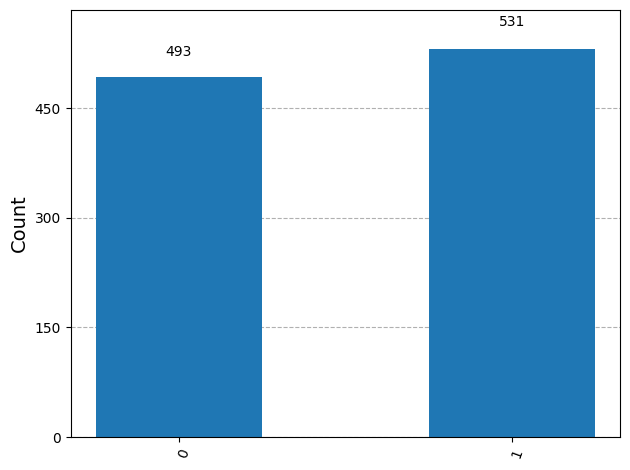

In [45]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

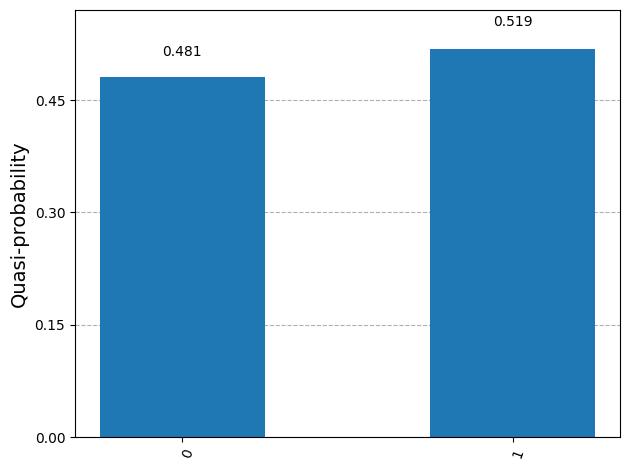

In [46]:
total_shots = sum(counts.values())
normalized_counts = {key: val / total_shots for key, val in counts.items()}

# Mostrar histograma
plot_histogram(normalized_counts)

### Ejercicio: Crear un estado de Bell

**Objetivo:** Construir un circuito cuántico que prepare el estado de Bell $ |\Phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle) $.

**Instrucciones:**

1. Crea un circuito cuántico con **2 qubits** y **2 bits clásicos**.
2. Aplica una compuerta **Hadamard (H)** al qubit 0.
3. Aplica una compuerta **CNOT** donde el **qubit 0 sea el control** y el **qubit 1 el objetivo**.
4. Dibujar el circuito esperado


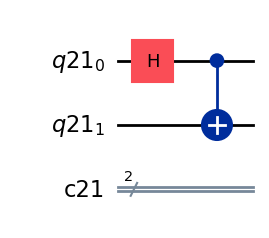

In [67]:
#Solucion

qreg = QuantumRegister(2)
creg = ClassicalRegister(2)

q_c = QuantumCircuit(qreg, creg)

q_c.h(0)

q_c.cx(0, 1)

q_c.draw(output='mpl')

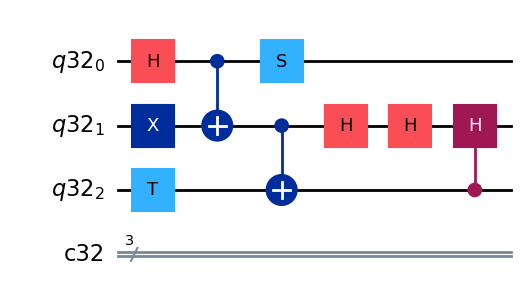

In [78]:
qreg = QuantumRegister(3)
creg = ClassicalRegister(3)

q_c = QuantumCircuit(qreg, creg)

q_c.h(0)

q_c.x(1)

q_c.cx(0, 1)

q_c.t(2)

q_c.cx(1, 2)

for i in range(2):
    q_c.h(1)

q_c.ch(2, 1)

q_c.s(0)


q_c.draw(output='mpl')